In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score

data = joblib.load("C:/CreditScoringMLE/ml_service/app/models/test_split_calibrated.joblib")
X_test = data["X_test"]
y_test = data["y_test"].to_numpy()
proba = data["calibrated_proba_test"]

print(X_test.shape, proba.mean(), y_test.mean())

(30752, 205) 0.08023666 0.08074271592091571


In [4]:
thresholds = np.linspace(0.01, 0.99, 100)
costs = []

for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # fn (approve дефолтера) — дорогая ошибка = $5000
    # fp (отказ хорошему клиенту) — дешёвая ошибка = $500
    cost = fn * 5000 + fp * 500
    costs.append(cost)

costs = np.array(costs)
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальный порог: {optimal_threshold:.3f}")
print(f"Минимальная стоимость: ${costs[optimal_idx]:,.0f}")
print(f"Стоимость при пороге 0.5 (baseline): ${costs[np.argmin(np.abs(thresholds - 0.5))]:,.0f}")

Оптимальный порог: 0.099
Минимальная стоимость: $7,365,000
Стоимость при пороге 0.5 (baseline): $12,010,500


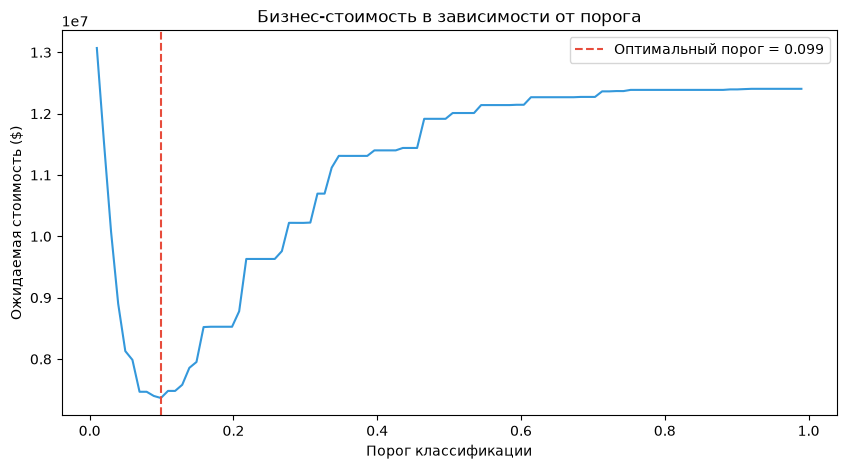

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color="#3498db")
ax.axvline(optimal_threshold, color="#e74c3c", linestyle="--", label=f"Оптимальный порог = {optimal_threshold:.3f}")
ax.set_xlabel("Порог классификации")
ax.set_ylabel("Ожидаемая стоимость ($)")
ax.set_title("Бизнес-стоимость в зависимости от порога")
ax.legend()
plt.show()

In [5]:
y_pred_optimal = (proba >= optimal_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.3f}")
print(f"Approval rate: {(y_pred_optimal == 0).mean():.1%}")


TN=21769, FP=6500, FN=823, TP=1660
Precision: 0.203
Recall: 0.669
Approval rate: 73.5%
